# Entregável 1 — Relatório de Aquisição dos Biossinais

**Disciplina:** Aquisição e Processamento de Biossinais  
**Equipe:** José Lessa & Matheus Rocha  
**Orientador:** Prof. Dr. Victor Hugo C. de Albuquerque  
**Dataset:** PTB-XL — A Large Publicly Available Electrocardiography Dataset (PhysioNet)  
**Referência:** Wagner et al. (2020). PTB-XL, a large publicly available electrocardiography dataset. *Scientific Data*, 7(1), 154.

---

## Objetivo

Este notebook documenta a etapa de **Aquisição dos Biossinais** do pipeline da disciplina, atendendo aos requisitos do Entregável 1. São abordados:

1. Caracterização do biossinal e do hardware de aquisição
2. Justificativa da taxa de amostragem via Teorema de Nyquist
3. Protocolo experimental e ambiente de coleta
4. Exploração dos metadados demográficos e diagnósticos
5. Visualização dos sinais brutos de ECG (12 derivações)
6. Identificação **visual** de possíveis problemas (saturação, drift de baseline e ruído de linha)

> **Nota metodológica:** O PTB-XL é um dataset público de referência internacional, com coleta realizada em ambiente hospitalar controlado, validado por especialistas cardiologistas. Os sinais brutos (.hea/.dat no formato WFDB) são carregados diretamente, sem nenhum pré-processamento, preservando as características originais de aquisição.


In [1]:
# Descomente a linha abaixo para instalar as dependências, se necessário
# !pip install -r ../../../requirements.txt

---
## 1. Configuração do Ambiente e Imports


In [2]:
import os
import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import wfdb
from pathlib import Path

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'font.family': 'DejaVu Sans',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.constrained_layout.use': False,
})

CORES = {
    'primaria':  '#1a3a5c',
    'secundaria': '#e74c3c',
    'ok':        '#2ecc71',
    'aviso':     '#f39c12',
    'info':      '#3498db',
    'neutro':    '#95a5a6',
}

DATA_DIR = Path('../../../data/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3')
FIG_DIR  = Path('../figuras')
OUT_DIR  = Path('../outputs')
for d in [FIG_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('✅ Configuração concluída.')
print(f'   Dados em : {DATA_DIR.resolve()}')
print(f'   Figuras em: {FIG_DIR.resolve()}')
print(f'   Outputs em: {OUT_DIR.resolve()}')


✅ Configuração concluída.
   Dados em : C:\Users\josel\OneDrive\Documentos\Biossinais\data\ptb-xl\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3
   Figuras em: C:\Users\josel\OneDrive\Documentos\Biossinais\entregaveis\entregavel-1\figuras
   Outputs em: C:\Users\josel\OneDrive\Documentos\Biossinais\entregaveis\entregavel-1\outputs


---
## 2. Download e Verificação do Dataset PTB-XL

O dataset PTB-XL está disponível publicamente no PhysioNet:  
https://physionet.org/content/ptb-xl/1.0.3/

A célula abaixo verifica se o dataset já está presente localmente antes de tentar download.


In [3]:
if not DATA_DIR.exists():
    print('Dataset não encontrado. Iniciando download do PhysioNet (pode levar vários minutos).')
    wfdb.dl_database('ptb-xl/1.0.3', dl_dir=str(DATA_DIR))
    print('Download concluído!')
else:
    arquivos_hea = list(DATA_DIR.rglob('*.hea'))
    print(f'Dataset encontrado em: {DATA_DIR.resolve()}')
    print(f'Arquivos de cabeçalho (.hea) localizados: {len(arquivos_hea)}')


Dataset encontrado em: C:\Users\josel\OneDrive\Documentos\Biossinais\data\ptb-xl\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3
Arquivos de cabeçalho (.hea) localizados: 43598


---
## 3. Descrição do Biossinal, Hardware e Protocolo de Aquisição

### 3.1 Tipo de Biossinal

O biossinal utilizado é o **Eletrocardiograma (ECG)** de **12 derivações** no padrão clínico internacional, composto por:

| Grupo | Derivações | Região monitorada |
|-------|-----------|-------------------|
| Membros (bipolares) | I, II, III | Plano frontal |
| Membros (unipolares aumentadas) | aVR, aVL, aVF | Plano frontal |
| Precordiais | V1, V2, V3, V4, V5, V6 | Plano horizontal |

O ECG registra a atividade elétrica cardíaca resultante da despolarização e repolarização do miocárdio, representada pelas ondas P, QRS e T. É o padrão-ouro para diagnóstico de arritmias, isquemia miocárdica, hipertrofia e diversas outras condições cardíacas.

---

### 3.2 Hardware e Sensor de Aquisição

Os registros foram adquiridos utilizando eletrocardiógrafos clínicos da **Schiller AG**, em ambiente hospitalar (Helios Klinikum, Berlim). O dataset apresenta 11 modelos distintos do fabricante, sendo o **CS100 3** o mais frequente (~28% dos registros). Tal informação sobre os dispostivos será vista na seção 4.1.

As especificações técnicas do conversor analógico-digital estão acessíveis diretamente nos cabeçalhos WFDB de cada registro, nos campos `adc_res` (resolução em bits), `adc_gain` (LSB/mV) e `baseline` (offset do ADC). Essas informações serão utilizadas posteriormente para o cálculo preciso dos limites de saturação — dispensando suposições sobre o hardware. As especificações restantes do equipamento (impedância de entrada, CMRR) não constam na documentação pública do dataset.

---

### 3.3 Taxa de Amostragem e Justificativa (Teorema de Nyquist-Shannon)

O dataset disponibiliza dois formatos de resolução temporal:

| Formato | Taxa de Amostragem | Amostras por registro (10s) | Uso recomendado |
|---------|-------------------|-----------------------------|-----------------|
| Alta resolução (HR) | **500 Hz** | 5.000 por derivação | Análise diagnóstica completa |
| Baixa resolução (LR) | **100 Hz** | 1.000 por derivação | Prototipagem / redução computacional |

**Fundamentação teórica — Teorema de Nyquist-Shannon:**

O teorema de Nyquist-Shannon estabelece que para reconstruir fielmente um sinal de banda limitada $f_{max}$, a taxa de amostragem $f_s$ deve satisfazer:

$$f_s \geq 2 \cdot f_{max}$$

Para o ECG clínico de 12 derivações, a *American Heart Association* (AHA) e o *American College of Cardiology* (ACC) recomendam preservar a faixa de **0,05 Hz a 150 Hz** para diagnóstico completo (incluindo alta frequência do QRS). Portanto:

$$f_s^{\min} = 2 \times 150 = 300 \text{ Hz}$$

A taxa de **500 Hz** supera o critério de Nyquist com **margem de segurança de 67%** ($500/300 \approx 1{,}67\times$), garantindo:
- Reconstrução fidedigna sem *aliasing*
- Resolução temporal suficiente para detecção precisa de picos R (duração ~10 ms) e ondas P estreitas
- Precisão no intervalo RR para análise de HRV (*Heart Rate Variability*)

A versão de 100 Hz preserva as morfologias principais (P, QRS, T), mas perde detalhes de alta frequência do QRS e é insuficiente para análise espectral completa — portanto, **utilizaremos 500 Hz como taxa principal** neste pipeline.

---

### 3.4 Protocolo Experimental

| Parâmetro | Descrição |
|-----------|----------|
| **Duração por registro** | 10 segundos |
| **Posição do paciente** | Não especificada; tipicamente supina em ECG de repouso |
| **Condições** | Ambiente clínico hospitalar controlado, paciente em repouso |
| **Período de coleta** | 1989 a 1996 |
| **Local** | Helios Klinikum, Berlim, Alemanha |
| **Padrão de colocação de eletrodos** | Não especificado; presumivelmente conforme padrões clínicos internacionais|
| **Validação clínica** | Laudo de pelo menos um cardiologista por registro; 72% com dois laudos |

---

### 3.5 Escala e Volume do Dataset

O PTB-XL é um dos maiores datasets públicos de ECG de 12 derivações do mundo:
- **21.799 registros de ECG** de **18.869 pacientes distintos**
- Anotações em hierarquia diagnóstica de 5 superclasses e 24 subclasses
- Metadados de qualidade do sinal anotados por especialistas
- Dados demográficos (idade, sexo) de todos os pacientes

---
## 4. Carregamento e Exploração dos Metadados


In [4]:
metadata_path = DATA_DIR / 'ptbxl_database.csv'
df = pd.read_csv(metadata_path, index_col='ecg_id')
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

n_registros = len(df)
n_pacientes = df['patient_id'].nunique()
n_dispositivos = df['device'].nunique()

print('=' * 55)
print('DATASET PTB-XL — VISÃO GERAL')
print('=' * 55)
print(f'Total de registros ECG : {n_registros:,}')
print(f'Pacientes únicos       : {n_pacientes:,}')
print(f'Dispositivos utilizados: {n_dispositivos}')
print('=' * 55)


DATASET PTB-XL — VISÃO GERAL
Total de registros ECG : 21,799
Pacientes únicos       : 18,869
Dispositivos utilizados: 11


### 4.1 Estatísticas Demográficas

O dataset apresenta distribuição de sexo equilibrada (52,1% masculino / 47,9% feminino), favorável para análises sem viés de gênero. A idade média de 62,8 anos reflete uma população predominantemente adulta/idosa — coerente com a alta prevalência de cardiopatias nessa faixa etária.

> O valor máximo de 300 anos corresponde a uma estratégia de anonimização do dataset, utilizada para representar pacientes com idade avançada (tipicamente ≥ 89 anos), conforme práticas comuns de proteção de dados em bases clínicas. Esse valor não deve ser interpretado literalmente e será tratado como uma categoria censurada (≥ 89 anos) nas análises subsequentes.

O hardware de aquisição é dominado pelo modelo Schiller **CS100 3** (6.140 registros, ~28%), com outros 10 modelos da mesma fabricante cobrindo o restante. A heterogeneidade inter-dispositivo pode introduzir variações nas características do sinal, sendo, portanto, um possível fator de confusão. O campo device será rastreado nos Entregáveis 2 e 4 para investigar eventuais correlações com artefatos como drift de baseline ou ruído de linha.

In [5]:
sex_map = {0: 'Masculino', 1: 'Feminino'}
sex_counts = df['sex'].map(sex_map).value_counts(dropna=False)
print('=== Distribuição por Sexo ===')
for s, n in sex_counts.items():
    print(f'  {s}: {n:,} ({100*n/len(df):.1f}%)')

print('\n=== Estatísticas de Idade ===')
print(df['age'].describe().to_string())

print('\n=== Dispositivos de Aquisição (Top 10) ===')
print(df['device'].value_counts().head(10).to_string())


=== Distribuição por Sexo ===
  Masculino: 11,354 (52.1%)
  Feminino: 10,445 (47.9%)

=== Estatísticas de Idade ===
count    21799.000000
mean        62.769301
std         32.308813
min          2.000000
25%         50.000000
50%         62.000000
75%         72.000000
max        300.000000

=== Dispositivos de Aquisição (Top 10) ===
device
CS100    3    6140
CS-12         4048
AT-6 C 5.5    3950
CS-12   E     2878
AT-6     6    2273
AT-60    3     966
AT-6 C 5.8     824
AT-6 C         514
AT-6 C 5.0      80
AT-6 C 5.3      67


### 4.2 Distribuição Diagnóstica

O PTB-XL organiza os diagnósticos em uma hierarquia de **5 superclasses** derivadas dos códigos do sistema SCP-ECG:

| Código | Superclasse | Descrição |
|--------|-------------|----------|
| NORM | Normal ECG | Ritmo sinusal normal, sem alterações |
| MI | Myocardial Infarction | Infarto do miocárdio (agudo ou antigo) |
| STTC | ST/T-wave Change | Alterações de segmento ST e onda T |
| CD | Conduction Disturbance | Bloqueios de ramo, distúrbios de condução |
| HYP | Hypertrophy | Hipertrofia ventricular/atrial |

Os resultados mostram que **43,6% dos registros são NORM** (ritmo sinusal sem alterações), com Infarto do Miocárdio (MI, 25,1%) e alterações de ST/T (STTC, 24,0%) compondo a maior parcela patológica — consistente com a origem hospitalar do dataset, predominantemente voltado a avaliação cardiológica.

> A soma das porcentagens ultrapassa 100% porque um mesmo registro pode receber **múltiplas superclasses**. Registros com diagnóstico misto exigem cuidado na definição do rótulo de classe única no Entregável 10, onde a estratégia de priorização adotada (`sc_primaria`) deverá ser reavaliada frente aos critérios de separabilidade estatística.

In [6]:
# ── Mapear superclasses diagnósticas ────────────────────────────────────────
# Carregar tabela de statements para mapear código → superclasse
scp_path = DATA_DIR / 'scp_statements.csv'
scp_df = pd.read_csv(scp_path, index_col=0)

# Criar mapeamento código → superclasse
codigo_para_superclasse = scp_df['diagnostic_class'].dropna().to_dict()

def obter_superclasses(scp_dict):
    """Retorna as superclasses diagnósticas de um registro."""
    superclasses = set()
    for codigo in scp_dict:
        if codigo in codigo_para_superclasse:
            sc = codigo_para_superclasse[codigo]
            if pd.notna(sc):
                superclasses.add(sc)
    return list(superclasses) if superclasses else ['Não diagnóstico']

df['superclasses'] = df['scp_codes'].apply(obter_superclasses)

# Contagem de registros por superclasse (um registro pode ter múltiplas)
from collections import Counter
contagem_sc = Counter(sc for lista in df['superclasses'] for sc in lista)
contagem_sc_df = pd.DataFrame(contagem_sc.items(),
                               columns=['Superclasse', 'Registros']
                              ).sort_values('Registros', ascending=False)

print('=== Distribuição por Superclasse Diagnóstica ===')
print('(Um registro pode ter mais de uma superclasse)\n')
for _, row in contagem_sc_df.iterrows():
    print(f"  {row['Superclasse']:>20s}: {row['Registros']:>6,} registros ({100*row['Registros']/n_registros:.1f}%)")

=== Distribuição por Superclasse Diagnóstica ===
(Um registro pode ter mais de uma superclasse)

                  NORM:  9,514 registros (43.6%)
                    MI:  5,469 registros (25.1%)
                  STTC:  5,235 registros (24.0%)
                    CD:  4,898 registros (22.5%)
                   HYP:  2,649 registros (12.2%)
       Não diagnóstico:    411 registros (1.9%)


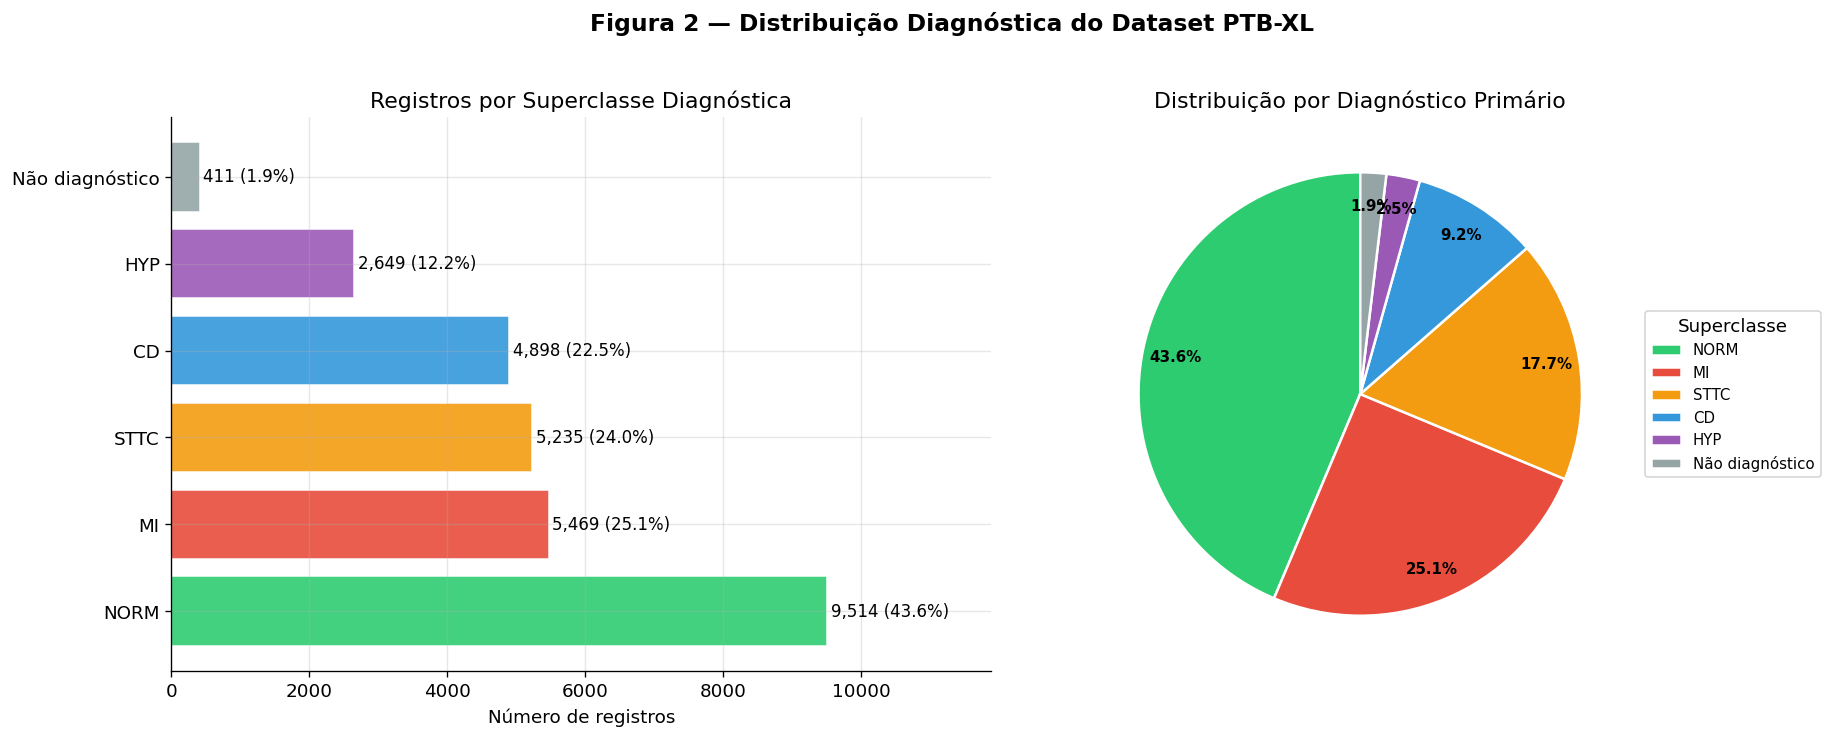

Figura 2 salva.


In [7]:
# ── Figura 2: Distribuição diagnóstica ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figura 2 — Distribuição Diagnóstica do Dataset PTB-XL',
             fontsize=14, fontweight='bold', y=1.02)

CORES_SC = {
    'NORM': '#2ecc71', 'MI': '#e74c3c', 'STTC': '#f39c12',
    'CD': '#3498db',   'HYP': '#9b59b6', 'Não diagnóstico': '#95a5a6'
}

# 2a — Barras horizontais
ax = axes[0]
cores_barras = [CORES_SC.get(sc, '#95a5a6') for sc in contagem_sc_df['Superclasse']]
bars = ax.barh(contagem_sc_df['Superclasse'], contagem_sc_df['Registros'],
               color=cores_barras, edgecolor='white', alpha=0.9)
for bar, val in zip(bars, contagem_sc_df['Registros']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({100*val/n_registros:.1f}%)',
            va='center', fontsize=10)
ax.set_xlabel('Número de registros')
ax.set_title('Registros por Superclasse Diagnóstica')
ax.set_xlim(0, contagem_sc_df['Registros'].max() * 1.25)

# 2b — Registros exclusivamente de cada superclasse (diagnóstico primário)
def superclasse_primaria(lista):
    prioridade = ['NORM', 'MI', 'STTC', 'CD', 'HYP', 'ND'] # Não Diagnóstico
    for p in prioridade:
        if p in lista:
            return p
    return lista[0]

df['sc_primaria'] = df['superclasses'].apply(superclasse_primaria)
sc_prim_counts = df['sc_primaria'].value_counts()

ax = axes[1]
wedge_colors = [CORES_SC.get(sc, '#95a5a6') for sc in sc_prim_counts.index]
wedges, texts, autotexts = ax.pie(
    sc_prim_counts.values,
    labels=None,
    colors=wedge_colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,   
    labeldistance=1.1,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for text in autotexts:
    text.set_fontsize(9)
    text.set_fontweight('bold')
ax.legend(
    wedges,
    sc_prim_counts.index,
    title='Superclasse',
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    fontsize=9
)
ax.set_title('Distribuição por Diagnóstico Primário')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig02_distribuicao_diagnostica.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 2 salva.')

---
## 5. Visualização dos Sinais Brutos de ECG (12 derivações)

Abaixo são plotados exemplos de ECG bruto (sem filtragem), para observação visual do traçado e de possíveis problemas (saturação, drift e ruído).


In [8]:
def carregar_ecg(ecg_id, df_meta, data_dir, sampling_rate=500):
    col = 'filename_hr' if sampling_rate == 500 else 'filename_lr'
    filename = df_meta.loc[ecg_id, col]
    return wfdb.rdrecord(str(data_dir / filename))

def plotar_ecg_12_derivacoes(record, ecg_id, df_meta=None, salvar_como=None):
    signal = record.p_signal
    fs = record.fs
    channels = record.sig_name
    t = np.arange(signal.shape[0]) / fs

    info_linha = f'ECG ID: {ecg_id} | {fs} Hz | {signal.shape[0]/fs:.0f}s | {signal.shape[1]} derivações'
    if df_meta is not None and ecg_id in df_meta.index:
        row = df_meta.loc[ecg_id]
        sexo_str = 'M' if row.get('sex', 0) == 0 else 'F'
        idade_str = f"{row.get('age', '?'):.0f} anos"
        info_linha += f' | Paciente: {sexo_str}, {idade_str}'

    fig = plt.figure(figsize=(20, 16))
    fig.suptitle(info_linha, fontsize=11, fontweight='bold', y=1.005)
    gs = gridspec.GridSpec(6, 2, figure=fig, hspace=0.45, wspace=0.25)

    for i in range(12):
        ax = fig.add_subplot(gs[i // 2, i % 2])
        sig = signal[:, i]
        ax.plot(t, sig, color=CORES['primaria'], linewidth=0.65, zorder=3)
        ax.set_ylabel(f'{channels[i]} (mV)', fontsize=9)
        ax.set_title(f'Derivação {channels[i]}', fontsize=10, fontweight='bold', loc='left', pad=2)
        ax.set_facecolor('#fffdf7')
        ax.grid(True, which='major', alpha=0.55, color='#e08080', linewidth=0.6, zorder=1)
        ax.grid(True, which='minor', alpha=0.2, color='#e08080', linewidth=0.3, zorder=1)
        ax.minorticks_on()
        ax.axhline(0, color='#888888', linewidth=0.5, linestyle='--', zorder=2)
        if i >= 10:
            ax.set_xlabel('Tempo (s)', fontsize=9)

    if salvar_como:
        plt.savefig(salvar_como, dpi=150, bbox_inches='tight')
        print(f'Figura salva: {salvar_como}')
    plt.show()


ECG IDs selecionados para visualização: [17136 11534 17974]
Figura salva: ..\figuras\ecg_bruto_17136.png


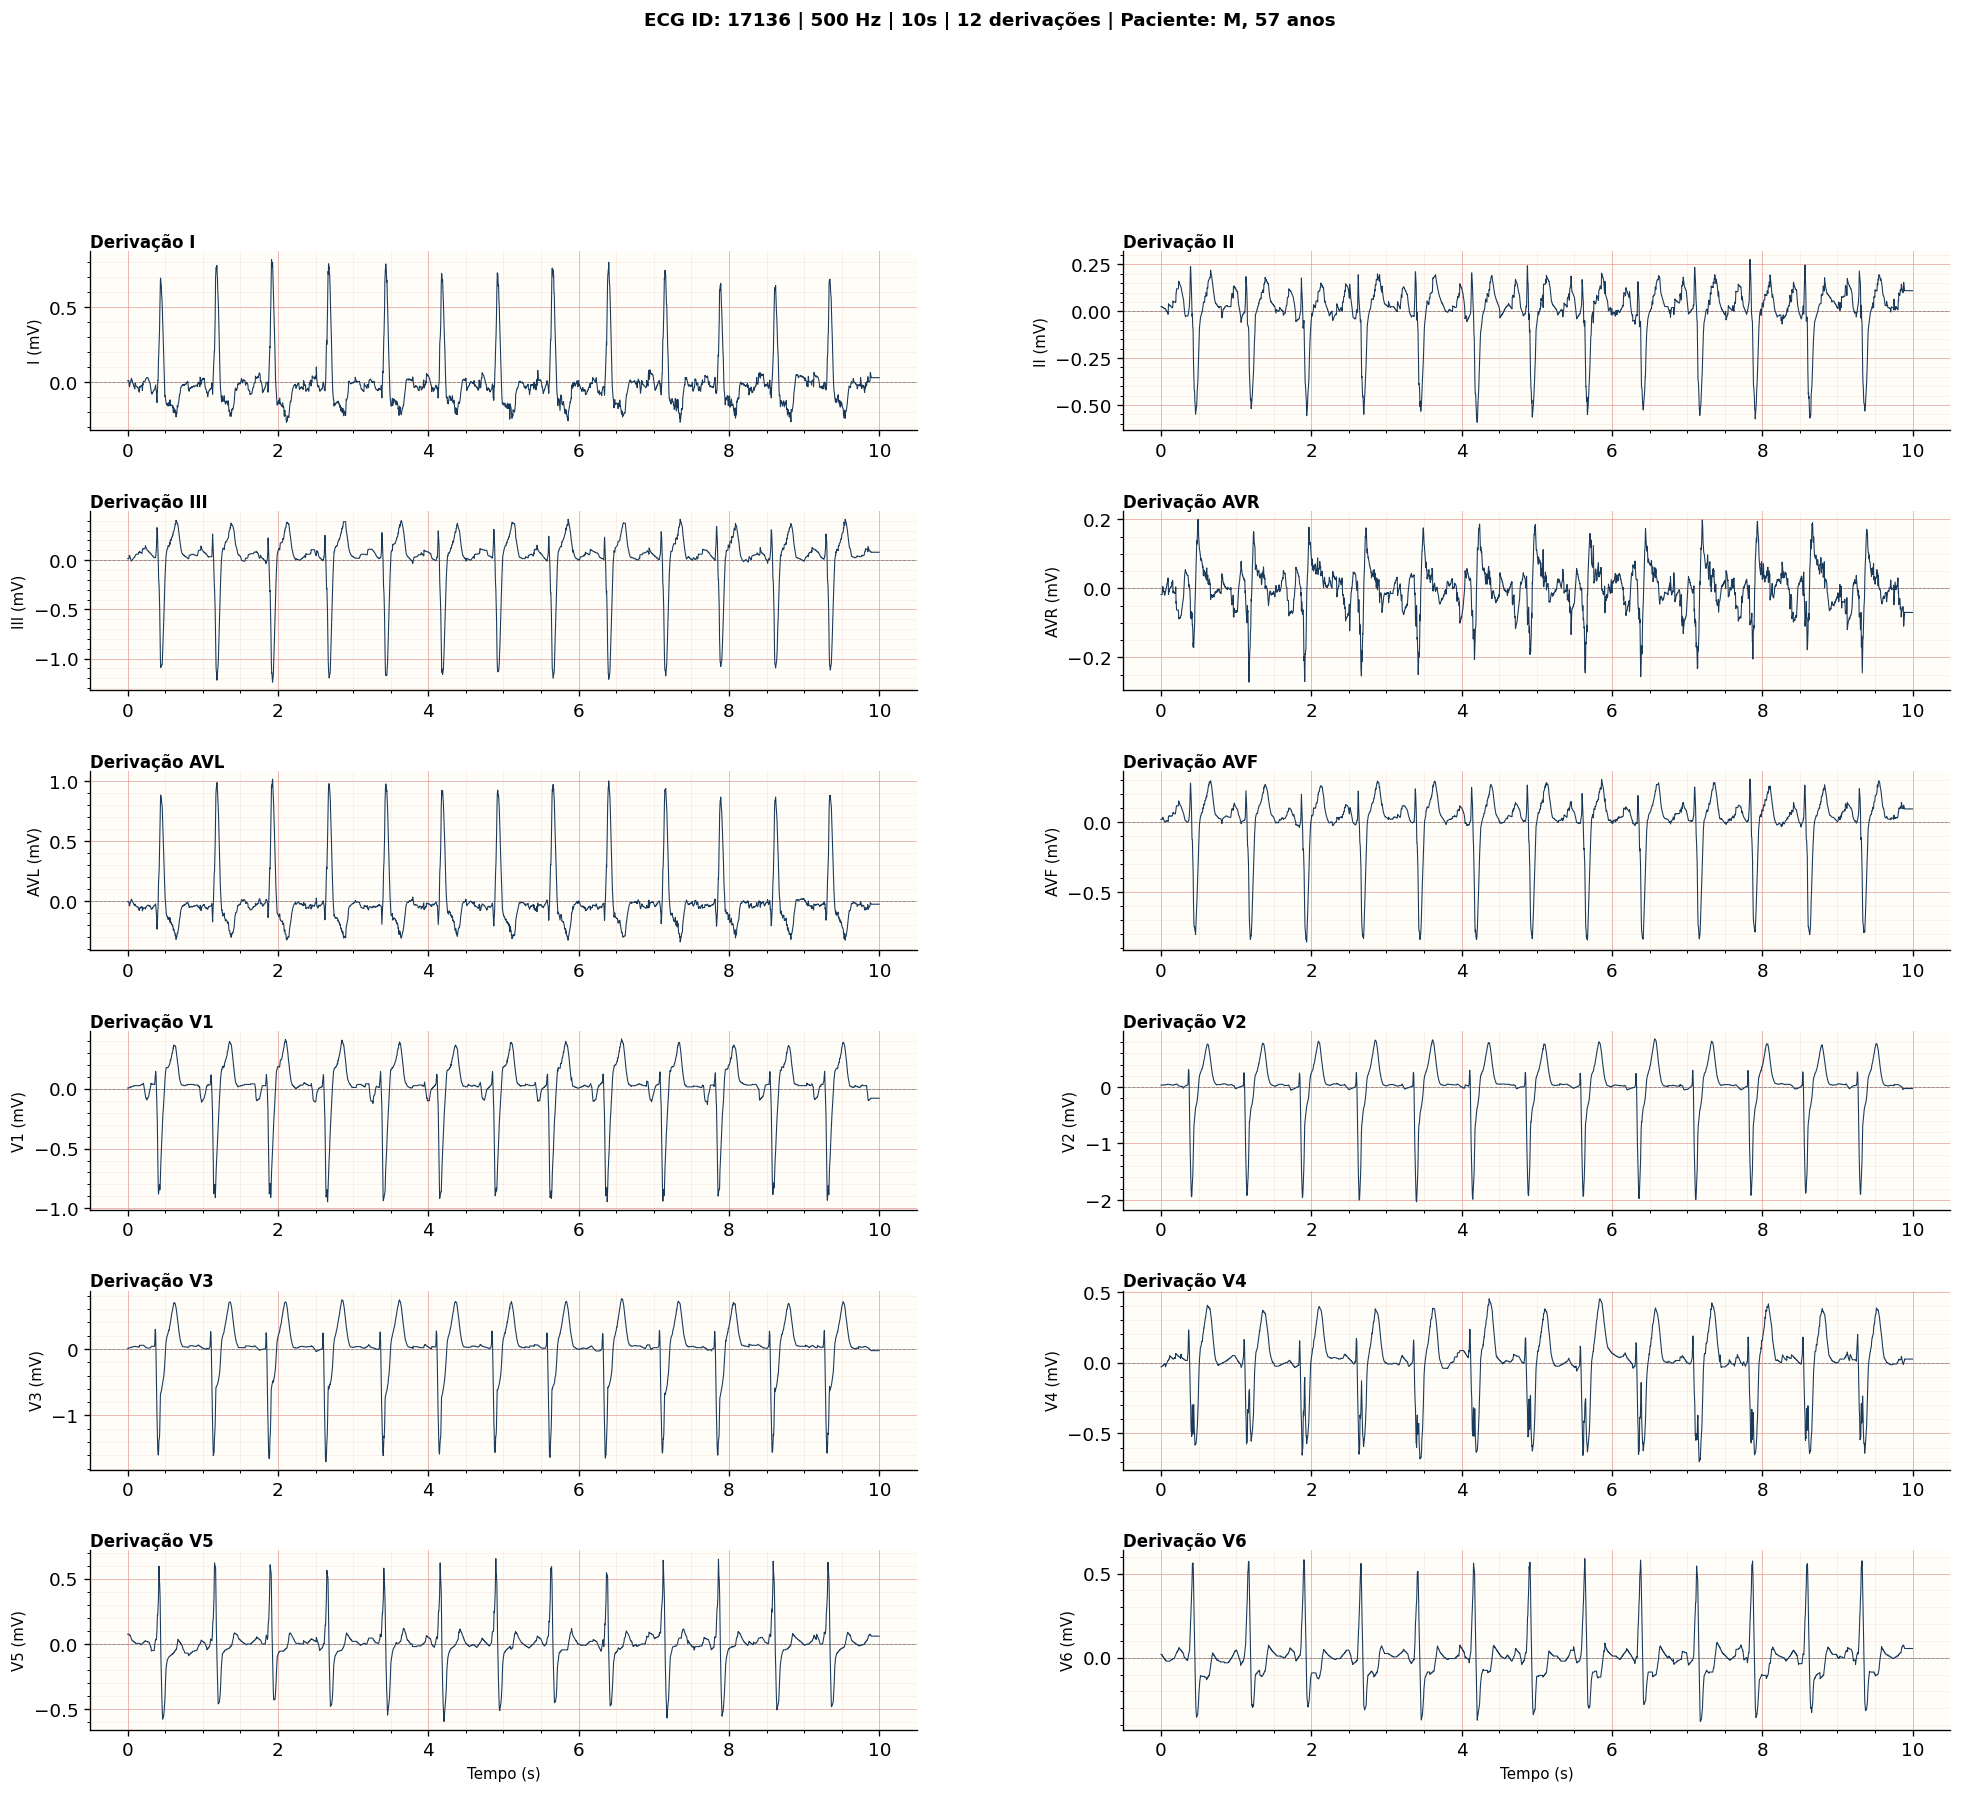

Figura salva: ..\figuras\ecg_bruto_11534.png


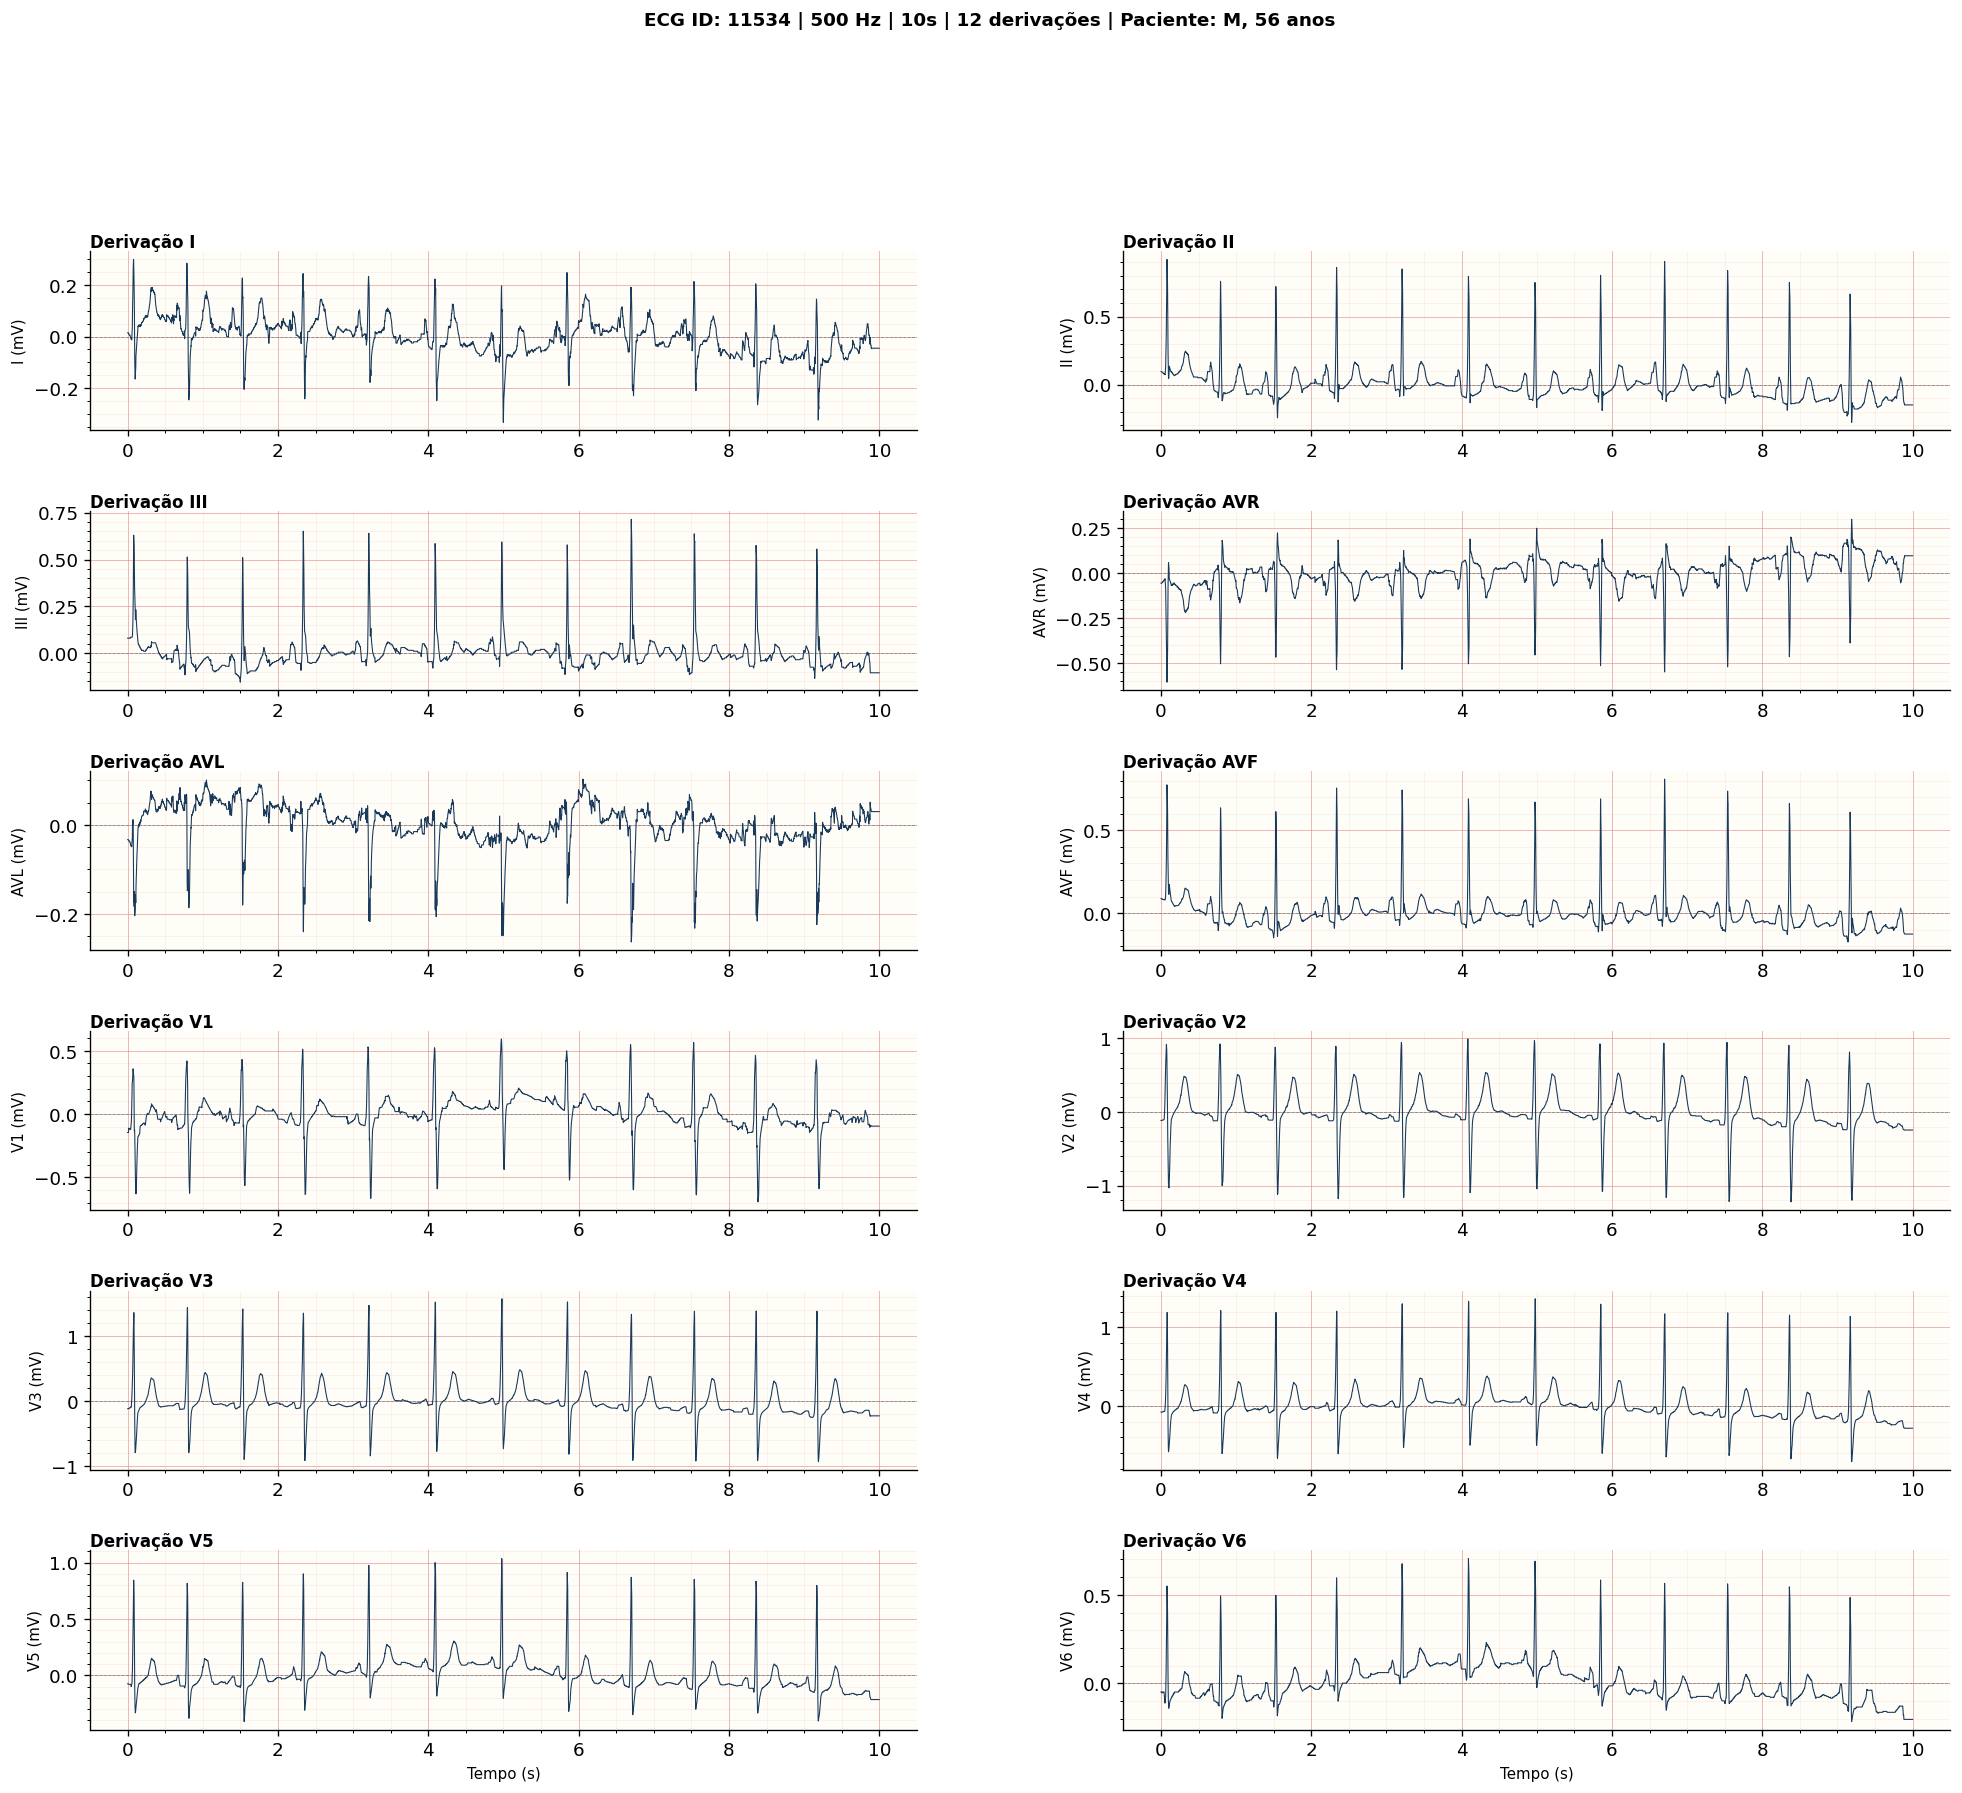

Figura salva: ..\figuras\ecg_bruto_17974.png


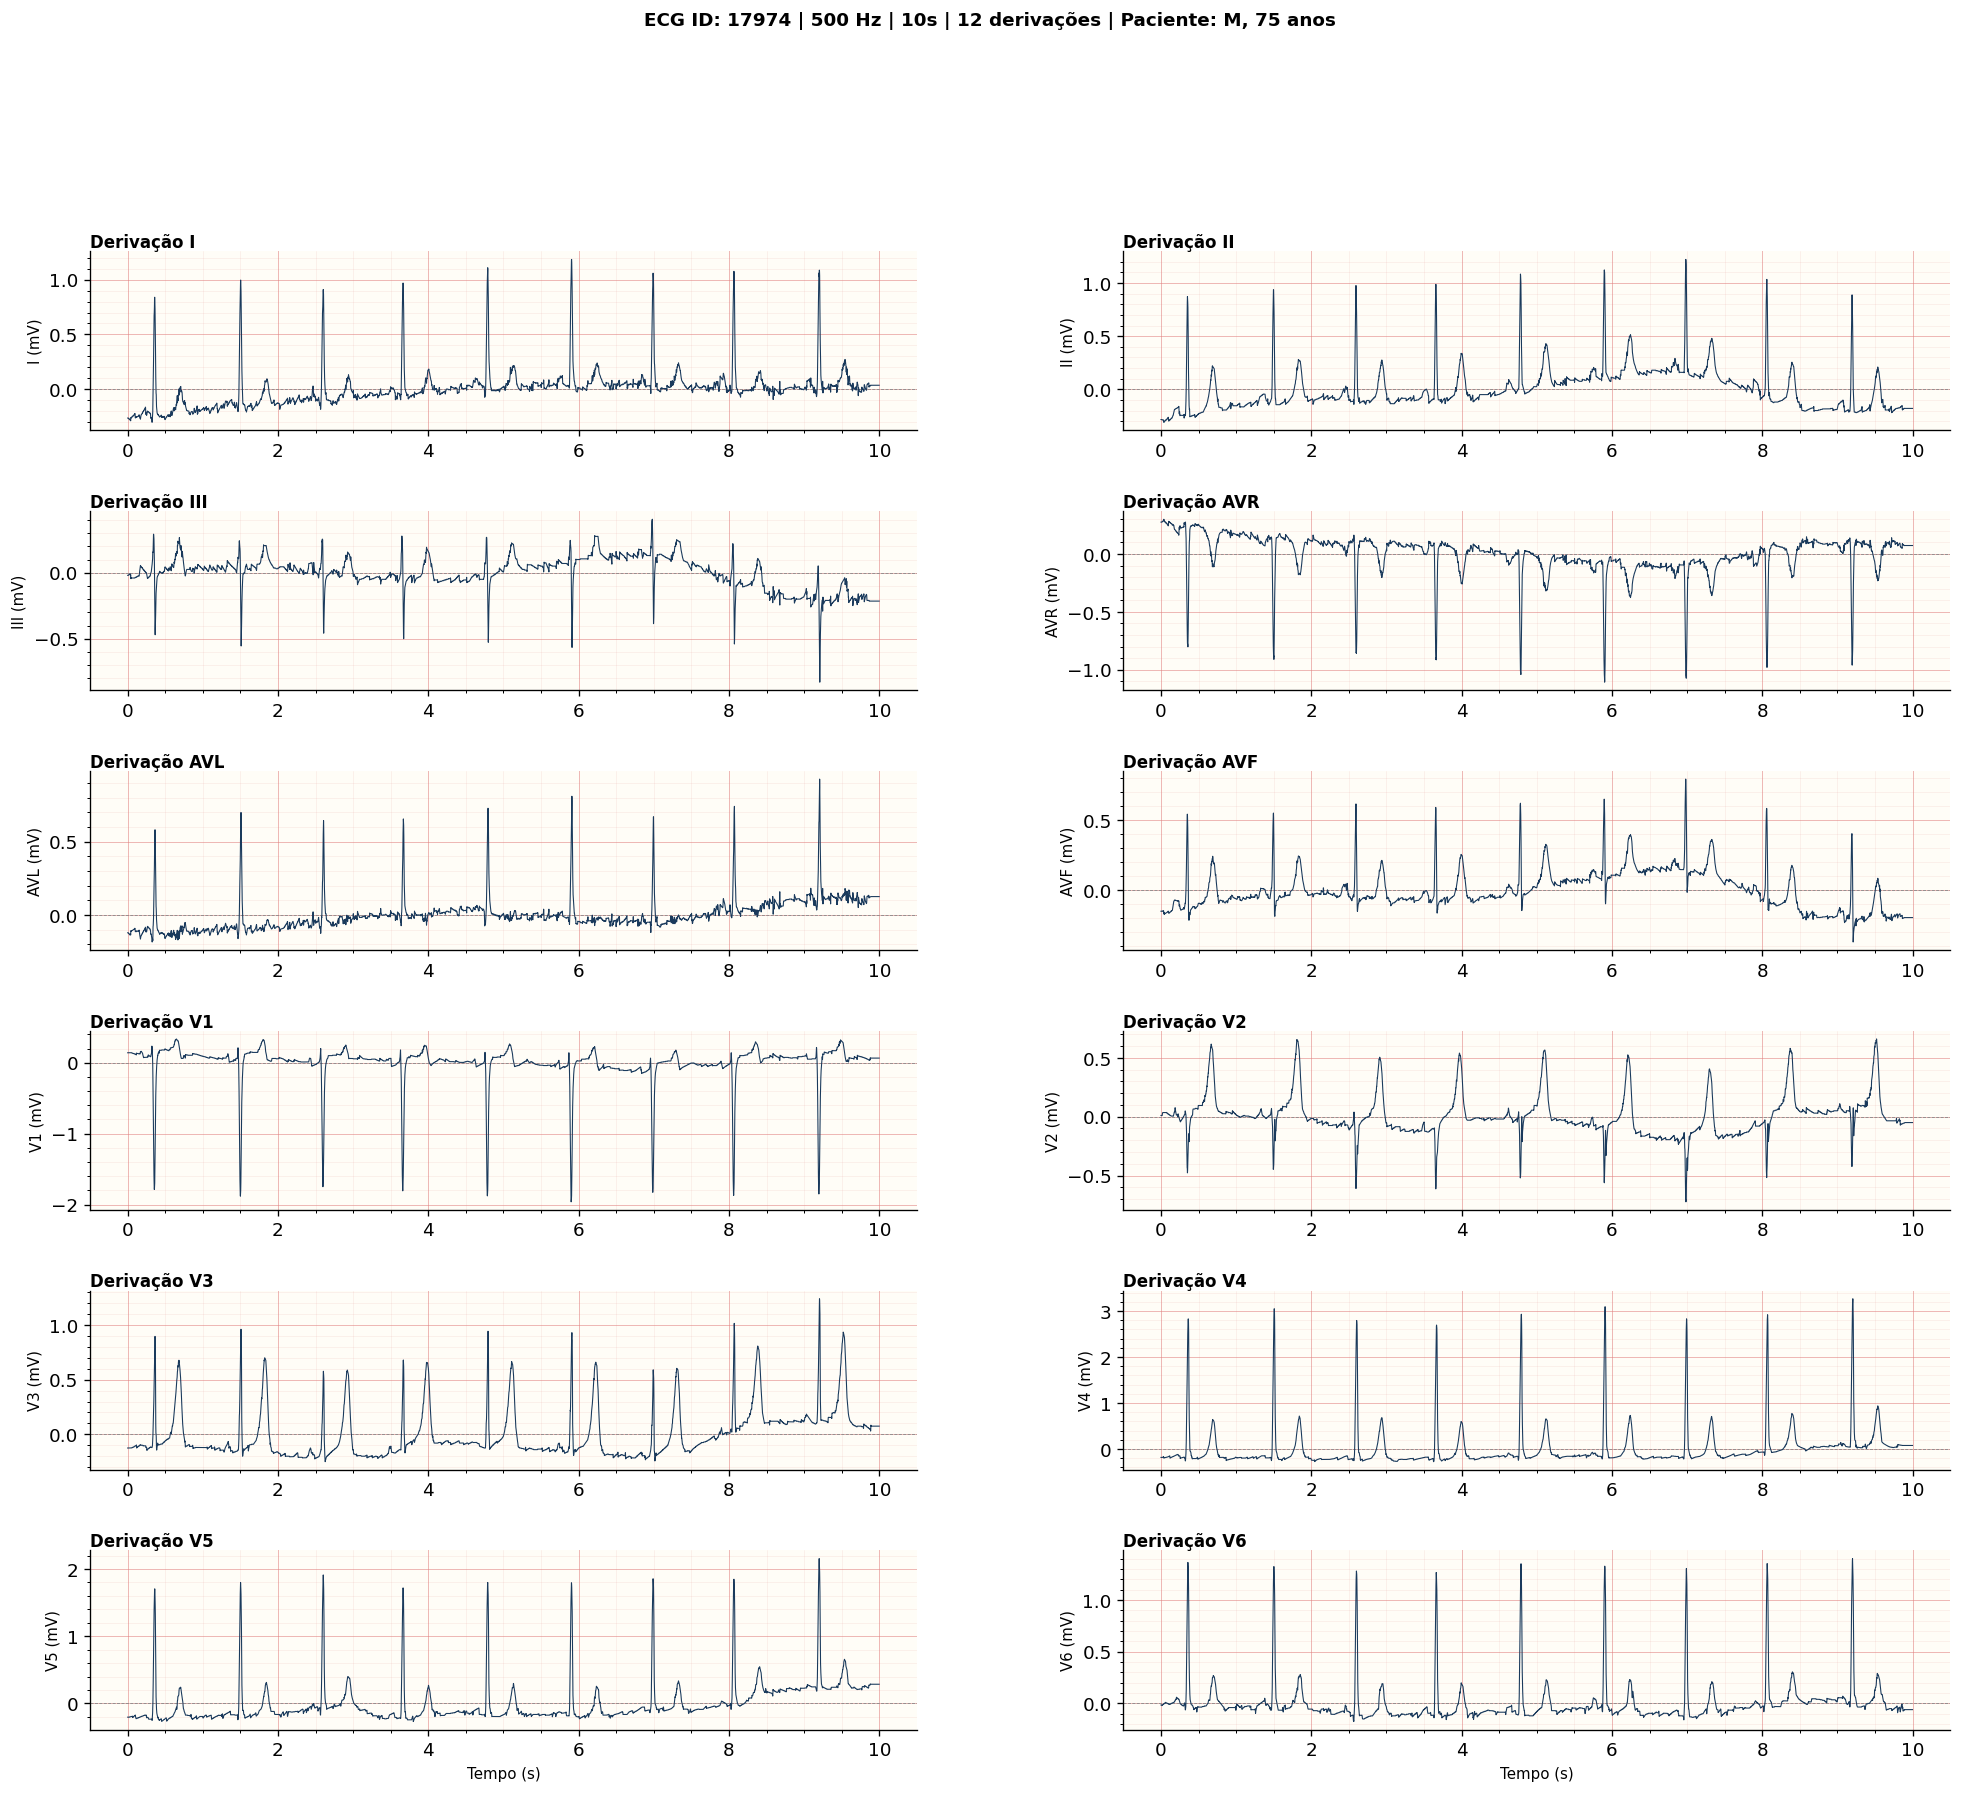

In [9]:
np.random.seed(42)
# Seleciona registros aleatórios para visualização (sem análise de qualidade quantitativa)
amostra_ids = np.random.choice(df.index.values, size=3, replace=False)
print('ECG IDs selecionados para visualização:', amostra_ids)

for ecg_id in amostra_ids:
    rec = carregar_ecg(int(ecg_id), df, DATA_DIR, sampling_rate=500)
    plotar_ecg_12_derivacoes(rec, int(ecg_id), df_meta=df, salvar_como=FIG_DIR / f'ecg_bruto_{int(ecg_id)}.png')


---
## 6. Identificação visual de possíveis problemas

Durante a inspeção dos gráficos do sinal bruto, foi possível observar o seguinte:

- **Saturação**: Nos sinais observados, não há evidência clara de saturação do sistema de aquisição. Os picos das ondas (principalmente complexos QRS) permanecem dentro de uma faixa dinâmica consistente, sem regiões de “achatamento” no topo ou base do sinal.
Em um sistema saturado, seria esperado observar trechos com amplitude constante (plateau), o que não ocorre nos segmentos analisados.

- **Drift de baseline**: É possível observar uma variação lenta do nível médio do sinal ao longo do tempo (baseline drift), perceptível principalmente nas regiões entre complexos QRS. Esse comportamento indica a presença de componentes de baixa frequência, possivelmente associados à respiração do paciente ou movimentação leve dos eletrodos. O drift ocorre em escala temporal maior que os eventos cardíacos, o que confirma sua natureza de baixa frequência.

- **Ruído de linha (50/60 Hz)**: Nota-se a presença de uma componente de alta frequência superposta ao sinal, visível como pequenas oscilações rápidas principalmente nas regiões isoelétricas. Esse padrão é compatível com interferência de rede elétrica (50/60 Hz), comum em ambientes hospitalares, especialmente quando não há filtragem notch aplicada na etapa de aquisição.

De forma geral, os sinais brutos apresentam boa preservação da morfologia cardíaca (ondas P, QRS e T identificáveis), porém com presença de artefatos típicos de aquisição: drift de baseline e interferência de linha.
Esses efeitos reforçam a necessidade de etapas posteriores de pré-processamento, como filtragem passa-alta (para remoção de drift) e filtro notch (para ruído de rede), conforme definido no pipeline.

A quantificação desses fenômenos e qualquer SQI serão tratados no **Entregável 2**.


---
## 7. Sumário Técnico (Entregável 1)


In [10]:
print('=' * 65)
print('SUMÁRIO TÉCNICO — ENTREGÁVEL 1: AQUISIÇÃO DOS BIOSSINAIS')
print('=' * 65)
print('Biossinal          : ECG de 12 derivações (padrão clínico)')
print('Hardware           : Schiller AG (ambiente hospitalar, Berlim)')
print('Taxa de amostragem : 500 Hz (HR) / 100 Hz (LR)')
print('Nyquist            : 500 Hz > 2×150 Hz = 300 Hz')
print('Protocolo          : Repouso, 10s, ambiente hospitalar')
print('Local / Período    : Helios Klinikum, Berlim, 1989–1996')
print('-' * 65)
print(f'Total de registros : {n_registros:,}')
print(f'Pacientes únicos   : {n_pacientes:,}')
print('=' * 65)


SUMÁRIO TÉCNICO — ENTREGÁVEL 1: AQUISIÇÃO DOS BIOSSINAIS
Biossinal          : ECG de 12 derivações (padrão clínico)
Hardware           : Schiller AG (ambiente hospitalar, Berlim)
Taxa de amostragem : 500 Hz (HR) / 100 Hz (LR)
Nyquist            : 500 Hz > 2×150 Hz = 300 Hz
Protocolo          : Repouso, 10s, ambiente hospitalar
Local / Período    : Helios Klinikum, Berlim, 1989–1996
-----------------------------------------------------------------
Total de registros : 21,799
Pacientes únicos   : 18,869
